# STAT 486 — Deliverable 2: Exploratory Data Analysis

---
## 1. Load & Inspect

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('flight_data_2024_sample.csv')

Shape: (10000, 35)


,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,4,18,4,2024-04-18,MQ,3535.0,DFW,"Dallas/Fort Worth, TX",Texas,...,0,151.0,144.0,119.0,835.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,AA,148.0,CLT,"Charlotte, NC",North Carolina,...,0,286.0,273.0,253.0,1773.0,0,0,0,0,0
2,2024,12,12,4,2024-12-12,9E,5440.0,CHA,"Chattanooga, TN",Tennessee,...,0,59.0,50.0,29.0,106.0,0,0,0,0,0


In [12]:
print('Shape:', df.shape)
print('\nColumn dtypes:')
print(df.dtypes)

Shape: (10000, 35)

Column dtypes:
year                     int64
month                    int64
day_of_month             int64
day_of_week              int64
fl_date                 object
op_unique_carrier       object
op_carrier_fl_num      float64
origin                  object
origin_city_name        object
origin_state_nm         object
dest                    object
dest_city_name          object
dest_state_nm           object
crs_dep_time             int64
dep_time               float64
dep_delay              float64
taxi_out               float64
wheels_off             float64
wheels_on              float64
taxi_in                float64
crs_arr_time             int64
arr_time               float64
arr_delay              float64
cancelled                int64
cancellation_code       object
diverted                 int64
crs_elapsed_time       float64
actual_elapsed_time    float64
air_time               float64
distance               float64
carrier_delay            int64
weat

In [13]:
print('\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing values:
dep_time                116
dep_delay               116
taxi_out                120
wheels_off              120
wheels_on               127
taxi_in                 127
arr_time                127
arr_delay               164
cancellation_code      9878
actual_elapsed_time     164
air_time                164
dtype: int64


---
## 2. Preprocessing

In [14]:
n_cancelled = df['cancelled'].sum()
print(f'Cancelled flights : {int(n_cancelled):,} ({n_cancelled/len(df)*100:.2f}%)')
print(f'Non-cancelled     : {int(len(df) - n_cancelled):,}')

code_map = {'A': 'Carrier', 'B': 'Weather', 'C': 'NAS', 'D': 'Security'}
print('\nCancellation reasons:')
print(df[df['cancelled'] == 1]['cancellation_code'].map(code_map).value_counts())

df_flights = df[df['cancelled'] == 0].copy()
df_flights.drop(columns=['cancelled', 'cancellation_code', 'diverted'], inplace=True)

Cancelled flights : 122 (1.22%)
Non-cancelled     : 9,878

Cancellation reasons:
cancellation_code
Weather    74
Carrier    31
NAS        17
Name: count, dtype: int64


In [16]:
missing = df_flights.isnull().sum()
missing = missing[missing > 0]
print('Missing values in modeling dataset:')
print(missing if len(missing) > 0 else 'None.')

before = len(df_flights)
df_flights.dropna(subset=['dep_delay', 'arr_delay'], inplace=True)
print(f'Rows dropped (missing dep_delay/arr_delay): {before - len(df_flights)}')
print(f'Final shape: {df_flights.shape}')

Missing values in modeling dataset:
wheels_on               5
taxi_in                 5
arr_time                5
arr_delay              42
actual_elapsed_time    42
air_time               42
dtype: int64
Rows dropped (missing dep_delay/arr_delay): 42
Final shape: (9836, 32)


---
## 3. Summary Statistics

In [35]:
key_cols = ['arr_delay', 'dep_delay', 'distance', 'taxi_out', 'crs_elapsed_time']
df_flights[key_cols].describe().round(2)

,arr_delay,dep_delay,distance,taxi_out,crs_elapsed_time
count,9836.00,9836.00,9836.00,9836.00,9836.00
mean,7.55,12.91,836.09,17.87,147.09
std,55.80,53.47,596.39,9.78,72.74
min,-78.00,-22.00,31.00,4.00,23.00
25%,-15.00,-6.00,403.75,12.00,93.00
50%,-6.00,-2.00,679.00,15.00,130.00
75%,10.00,9.00,1069.75,21.00,178.00
max,2014.00,2011.00,5095.00,154.00,685.00


---
## 4. Visual Exploration

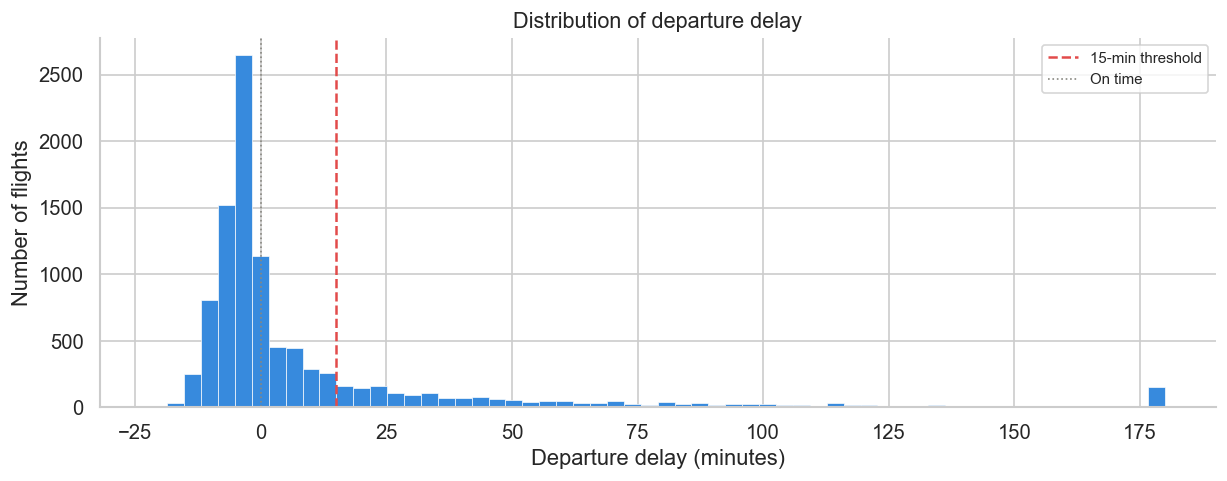

In [29]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.hist(df_flights['dep_delay'].clip(-60, 180), bins=60,
        color='#378ADD', edgecolor='white', linewidth=0.4)
ax.axvline(15, color='#E24B4A', linewidth=1.5, linestyle='--', label='15-min threshold')
ax.axvline(0,  color='#888780', linewidth=1,   linestyle=':',  label='On time')
ax.set_xlabel('Departure delay (minutes)')
ax.set_ylabel('Number of flights')
ax.set_title('Distribution of departure delay', fontsize=13, fontweight='normal')
ax.legend(fontsize=9)

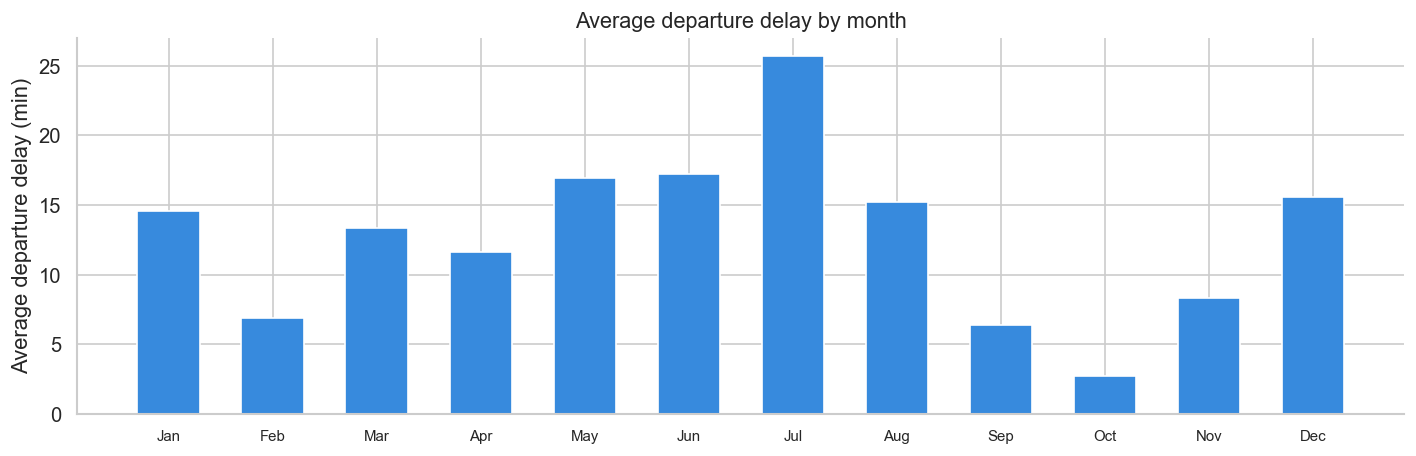

In [30]:
fig, ax = plt.subplots(figsize=(12, 4))
monthly = df_flights.groupby('month')['dep_delay'].mean()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.bar(monthly.index, monthly.values, color='#378ADD', width=0.6)
ax.set_xticks(range(1,13))
ax.set_xticklabels(month_labels, fontsize=9)
ax.axhline(0, color='#888780', linewidth=0.8)
ax.set_ylabel('Average departure delay (min)')
ax.set_title('Average departure delay by month', fontsize=13, fontweight='normal')

plt.tight_layout()
plt.savefig('viz1_dep_delay_distribution.png', bbox_inches='tight')
plt.show()

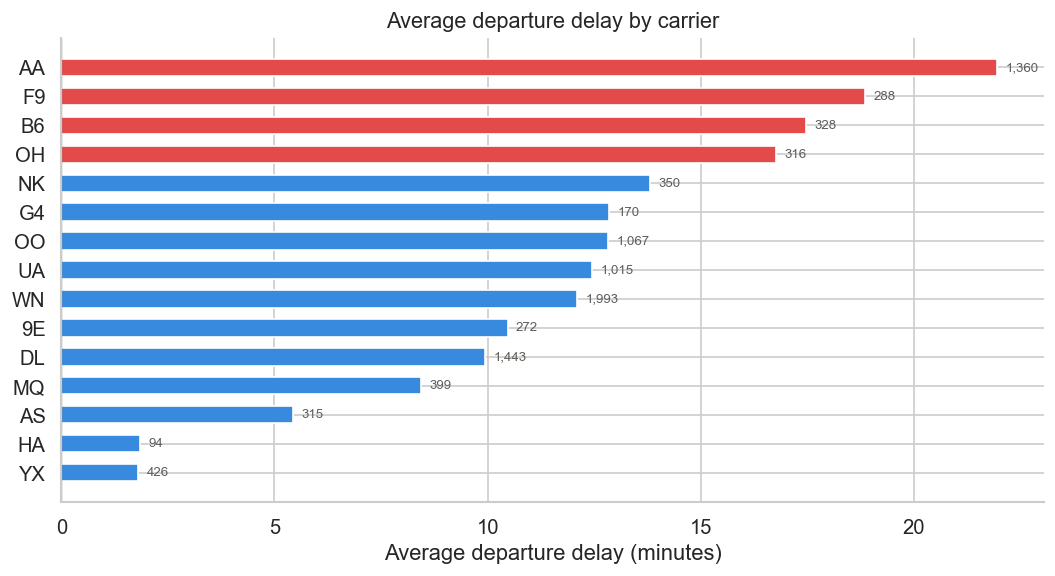

In [27]:
carrier_stats = (df_flights.groupby('op_unique_carrier')['dep_delay']
                 .agg(['mean','count'])
                 .reset_index()
                 .sort_values('mean', ascending=True))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E24B4A' if v > 15 else '#378ADD' for v in carrier_stats['mean']]
ax.barh(carrier_stats['op_unique_carrier'], carrier_stats['mean'], color=colors, height=0.6)
ax.axvline(0, color='#888780', linewidth=0.8)
ax.set_xlabel('Average departure delay (minutes)')
ax.set_title('Average departure delay by carrier', fontsize=13, fontweight='normal')
for i, (_, row) in enumerate(carrier_stats.iterrows()):
    ax.text(row['mean'] + 0.2, i, f"{int(row['count']):,}", va='center', fontsize=8, color='#5F5E5A')
plt.tight_layout()
plt.savefig('viz2_carrier_dep_delay.png', bbox_inches='tight')
plt.show()

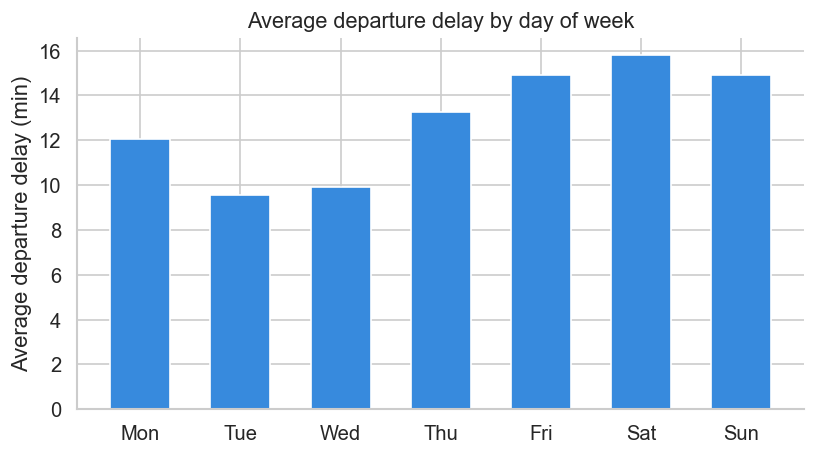

In [32]:
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_delay = df_flights.groupby('day_of_week')['dep_delay'].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1,8), dow_delay.values, color='#378ADD', width=0.6)
ax.set_xticks(range(1,8))
ax.set_xticklabels(dow_labels)
ax.axhline(0, color='#888780', linewidth=0.8)
ax.set_ylabel('Average departure delay (min)')
ax.set_title('Average departure delay by day of week', fontsize=13, fontweight='normal')
plt.tight_layout()
plt.savefig('viz5_dow_delay.png', bbox_inches='tight')
plt.show()

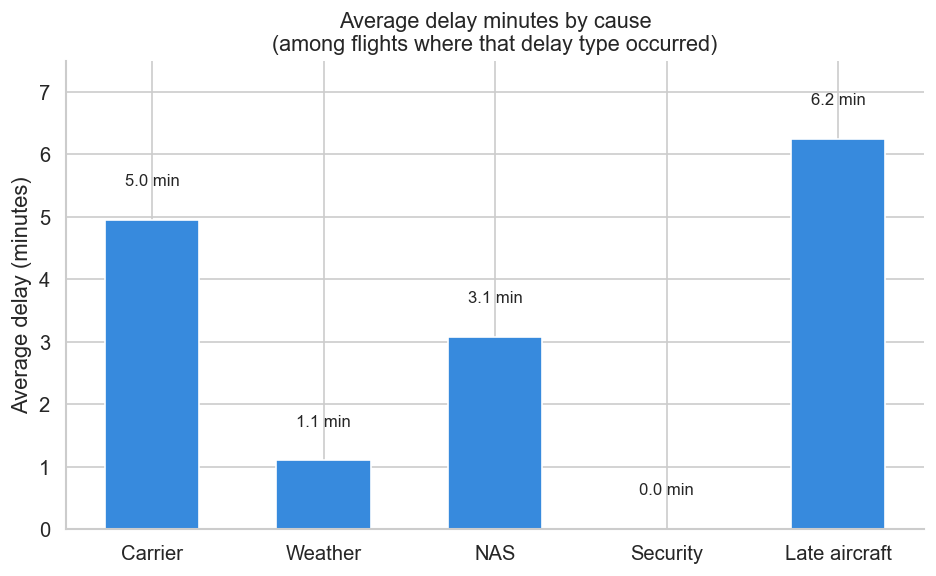

In [34]:
delay_causes = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
cause_labels = ['Carrier', 'Weather', 'NAS', 'Security', 'Late aircraft']

means_delayed = df_flights[delay_causes].mean()

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(cause_labels, means_delayed.values, color='#378ADD', width=0.55)

for bar, val in zip(bars, means_delayed.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f} min', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Average delay (minutes)')
ax.set_title('Average delay minutes by cause\n(among flights where that delay type occurred)',
             fontsize=13, fontweight='normal')
ax.set_ylim(0, means_delayed.max() * 1.2)

plt.tight_layout()
plt.savefig('viz_delay_causes_bar.png', bbox_inches='tight')
plt.show()